# CSCE 40103 Module 2 - Lab 1
## PHISHING URL CLASSIFICATION WITH DATA CLEANING, FEATURE PREPARATION, CROSS-VALIDATION, AND TUNING

**Dataset used:** PhiUSIIL_Phishing_URL_Dataset, UNSW_NB15_training-set.csv, UNSW_NB15_testing-set.csv


## 1. Setup



In [132]:
from pathlib import Path
from io import StringIO
import base64
import gzip

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, RocCurveDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV_PHI = Path("PhiUSIIL_Phishing_URL_Dataset.csv")
LOCAL_CSV_UNSW_TRAIN = Path("UNSW_NB15_training-set.csv")
LOCAL_CSV_UNSW_TEST = Path("UNSW_NB15_testing-set.csv")

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## 2. Load the Datasets

Load the PhiUSIIL dataset into a DataFrame named df_phish.
Load the USNW dataset into a DataFrame named df_unsw.


In [133]:
def load_phishing_dataset(local_csv: Path = LOCAL_CSV_PHI) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df

df_phish = load_phishing_dataset()
print("Phish dataset loaded successfully.")
print("Shape:", df_phish.shape)
df_phish.head()

Loading local CSV file: PhiUSIIL_Phishing_URL_Dataset.csv
Phish dataset loaded successfully.
Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [134]:
def load_unsw_dataset(local_csv: Path) -> pd.DataFrame:
    # Load a UNSW-NB15 CSV from disk (no internet or package installation).
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")
    return loaded_df

df_unsw = load_unsw_dataset(LOCAL_CSV_UNSW_TRAIN)
df_unsw_test = load_unsw_dataset(LOCAL_CSV_UNSW_TEST)
print("UNSW datasets loaded successfully.")
print("Training shape:", df_unsw.shape)
print("Testing shape:", df_unsw_test.shape)
df_unsw.head()

Loading local CSV file: UNSW_NB15_training-set.csv
Loading local CSV file: UNSW_NB15_testing-set.csv
UNSW datasets loaded successfully.
Training shape: (175341, 45)
Testing shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## 3: Inspect the Datasets

Display the dataset size, column names, and data types for df_phish and df_unsw

In [135]:
print("Rows and columns:", df_phish.shape)
print("Column names:")
print(df_phish.columns)
print("Dataset information:")
df_phish.info()

Rows and columns: (235795, 56)
Column names:
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'N

In [136]:
print("Rows and columns:", df_unsw.shape)
print("Column names:")
print(df_unsw.columns)
print("Dataset information:")
df_unsw.info()

Rows and columns: (175341, 45)
Column names:
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload',
       'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl',
       'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='str')
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service      

## 4: Check Missing Values and Duplicate Rows

Check whether the datasets contain missing values and/or duplicate rows.

In [137]:
missing_values_phish = df_phish.isnull().sum()
print(missing_values_phish[missing_values_phish > 0])
duplicate_count_phish = df_phish.duplicated().sum()
print("Number of duplicate rows:", duplicate_count_phish)

Series([], dtype: int64)
Number of duplicate rows: 0


In [138]:
missing_values_unsw = df_unsw.isnull().sum()
print(missing_values_unsw[missing_values_unsw > 0])
duplicate_count_unsw = df_unsw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count_unsw)

Series([], dtype: int64)
Number of duplicate rows: 0


## 5: Inspect the Target Variable

Display class counts and percentages, then create a class distribution plot

Class counts:
label
1    134850
0    100945
Name: count, dtype: int64
Class percentages:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


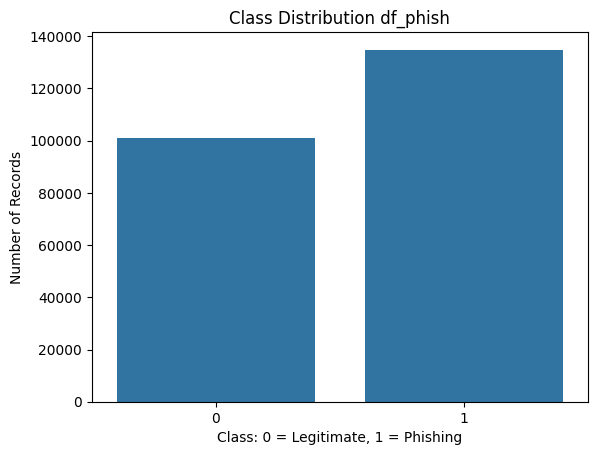

In [139]:
class_counts_phish = df_phish["label"].value_counts()
class_percentages_phish = df_phish["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts_phish)
print("Class percentages:")
print(class_percentages_phish.round(2))
sns.countplot(data=df_phish, x="label")
plt.title("Class Distribution df_phish")
plt.xlabel("Class: 0 = Legitimate, 1 = Phishing")
plt.ylabel("Number of Records")
plt.show()

Class counts:
label
1    119341
0     56000
Name: count, dtype: int64
Class percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64


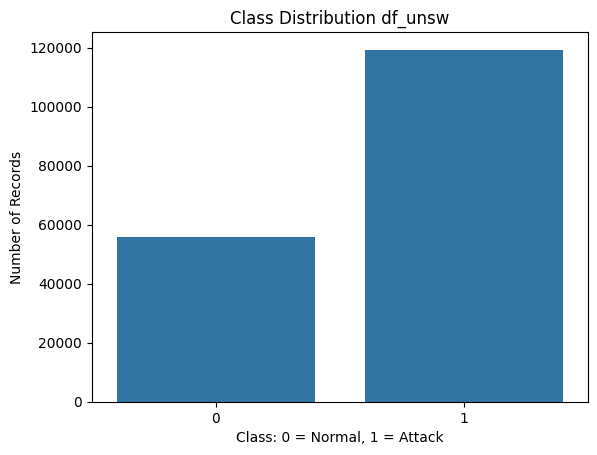

In [140]:
class_counts_unsw = df_unsw["label"].value_counts()
class_percentages_unsw = df_unsw["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts_unsw)
print("Class percentages:")
print(class_percentages_unsw.round(2))
sns.countplot(data=df_unsw, x="label")
plt.title("Class Distribution df_unsw")
plt.xlabel("Class: 0 = Normal, 1 = Attack")
plt.ylabel("Number of Records")
plt.show()

The class distribution for df_phish dataset is slightly imbalanced leaning more towards fishing. The df_unsw dataset appears to be quite imbalanced. In real life phishing attacks are much less common than just normal communication so this will start to bias the model towards 'thinking' there are more attacks then there really is. 

## 6: Select Useful Features

PhiUSIIL: prioritize URL structure, webpage behavior, and URL characteristics. 
UNSW-NB15: prioritize network-flow behavior and traffic characteristics.

In [141]:
candidate_features_phish = [
"URLLength",
"DomainLength",
"NoOfSubDomain",
"NoOfLettersInURL",
"NoOfDegitsInURL",
"NoOfOtherSpecialCharsInURL",
"IsHTTPS",
"NoOfExternalRef",
"LineOfCode",
"LargestLineLength"
]
selected_features_phish = []
for col in candidate_features_phish:
    if col in df_phish.columns:
        selected_features_phish.append(col)
print("Selected features:")
print(selected_features_phish)

Selected features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength']


|Dataset|Selected Feature|Reason for Selecting It|
| --- | --- | --- |
| PhiUSIIL | ['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength'] |  These features prioritize url structure and characteristics (e.g. URLLength/DomainLength/NoOfLettersInUrl). It also covers URL characteristics like IsHTTPS. These are helpful for identifying anomalistic URL’s. |

In [142]:
candidate_features_unsw = [
    "dur",      # flow duration
    "spkts",    # source -> dest packet count
    "dpkts",    # dest -> source packet count
    "sbytes",   # source -> dest bytes
    "dbytes",   # dest -> source bytes
    "rate",     # packets per second
    "sload",    # source bits per second
    "dload",    # destination bits per second
    "sttl",     # source-to-dest time-to-live
    "dttl",     # dest-to-source time-to-live
]
selected_features_unsw = []
for col in candidate_features_unsw:
    if col in df_unsw.columns:
        selected_features_unsw.append(col)
print("Selected features:")
print(selected_features_unsw)

Selected features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl']


|Dataset|Selected Feature|Reason for Selecting It|
| --- | --- | --- |
| UNSW-NB15 | ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl'] |   The characteristics chosen for this dataset were primarily centered around network-flow/traffic characteristics. Insight into the sttl/dttl is insightful to know how many routers the packet is hitting, spkts/dpkts helps to analyze the ratio of traffic coming and going. 

## 7: Explore Numeric Feature Distributions

Create histograms for important numeric features

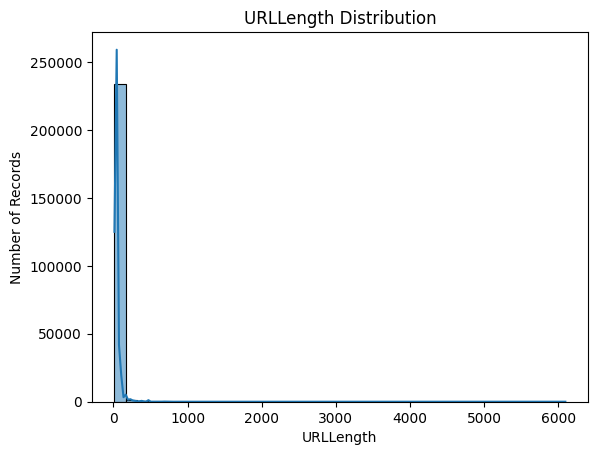

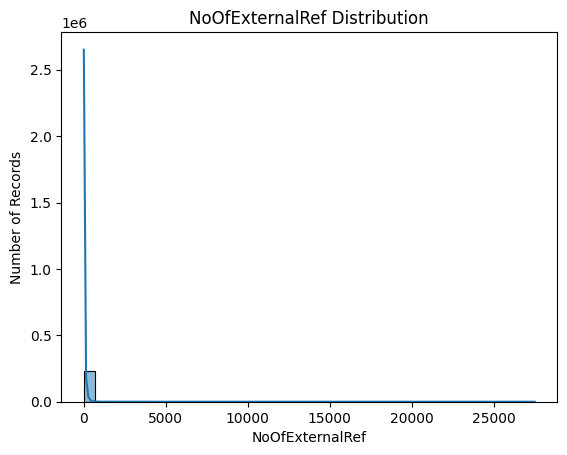

In [143]:
features_to_plot_phish = ["URLLength", "NoOfExternalRef"]
for feature in features_to_plot_phish:
    if feature in df_phish.columns:
        sns.histplot(data=df_phish, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

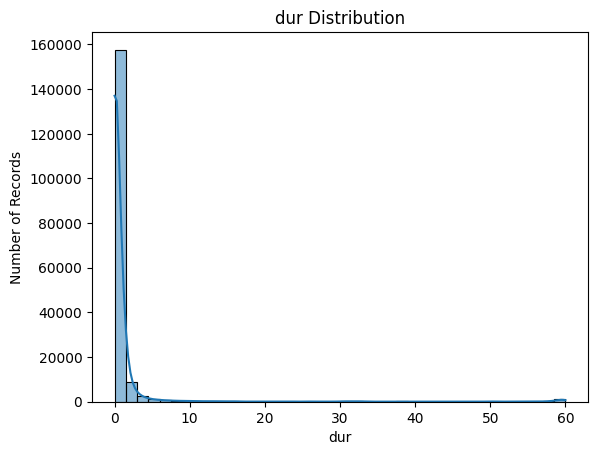

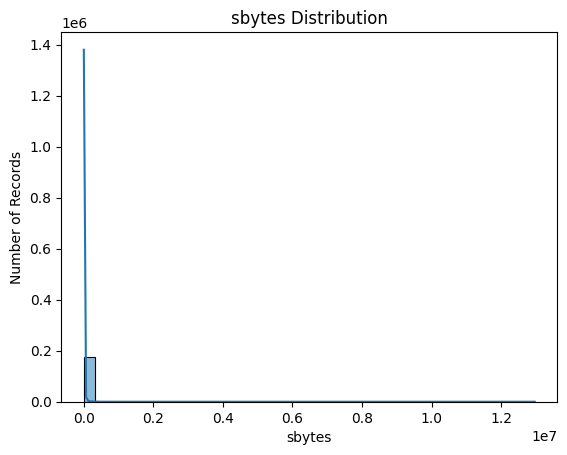

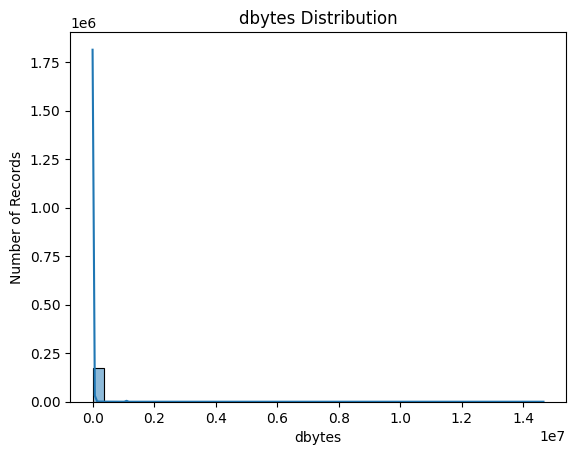

In [144]:
features_to_plot_unsw = ["dur", "sbytes", "dbytes"]
for feature in features_to_plot_unsw:
    if feature in df_unsw.columns:
        sns.histplot(data=df_unsw, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

## 8: Basic Feature Engineering
Create log-transformed versions of skewed numeric features.

| Dataset | Engineered Features | Formula / Description | Why It May Help |
| --- | --- | --- | --- |
| PhiUSIIL | URLLength | np.log1p(work_df["URLLength"]) | URL length is skewed, this compresses the results to prevent outliers from dominating
| PhiUSIIL | NoOfExternalRef | np.log1p(work_df["NoOfExternalRef"]) | There are a lot of zero's for this feature so this will keep 0's quantifiable. 

In [145]:
work_df_phish = df_phish.copy()
if "URLLength" in work_df_phish.columns:
    work_df_phish["log_URLLength"] = np.log1p(work_df_phish["URLLength"])
if "NoOfExternalRef" in work_df_phish.columns:
    work_df_phish["log_NoOfExternalRef"] = np.log1p(work_df_phish["NoOfExternalRef"])
work_df_phish.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label,log_URLLength,log_NoOfExternalRef
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1,3.465736,4.828314
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1,3.178054,5.384495
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1,3.401197,1.791759
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1,3.295837,3.465736
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1,3.526361,4.454347


| Dataset | Engineered Features | Formula / Description | Why It May Help |
| --- | --- | --- | --- |
| UNSW-NB15 | sbytes and dbytes ratio | work_df_unsw["sbytes"] / (work_df_unsw["dbytes"] + 1)  | This will help get a better idea of the bytes flowing.
| UNSW-NB15 | NoOfExternalRef | np.log1p(work_df["NoOfExternalRef"]) | duration is heavily skewed, this should help compress the data. 

In [146]:
def engineer_unsw(df):
    df = df.copy()
    if "sbytes" in df.columns and "dbytes" in df.columns:
        df["byte_ratio"] = np.log1p(df["sbytes"]) / np.log1p(df["dbytes"])
    if "dur" in df.columns:
        df["log_dur"] = np.log1p(df["dur"])
    return df

work_df_train_unsw = engineer_unsw(df_unsw)        
work_df_test_unsw = engineer_unsw(df_unsw_test)    

## 9: Compare Raw and Log-Transformed Values
Create raw and log-transformed histograms for URLLength.

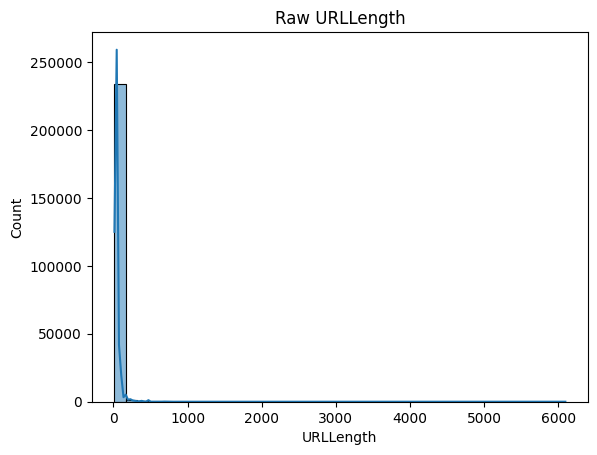

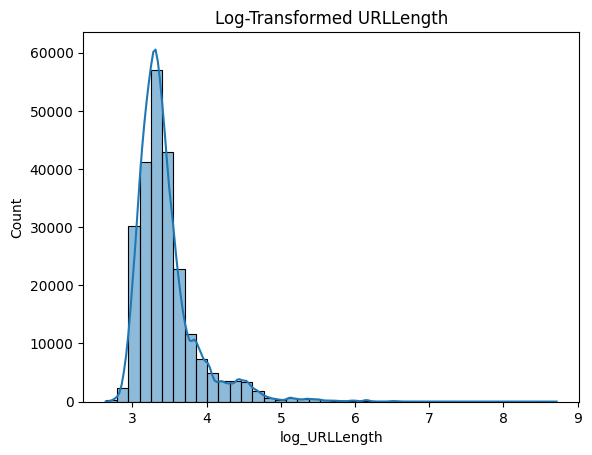

In [147]:
if "URLLength" in work_df_phish.columns:
    sns.histplot(data=work_df_phish, x="URLLength", bins=40, kde=True)
    plt.title("Raw URLLength")
    plt.show()
    sns.histplot(data=work_df_phish, x="log_URLLength", bins=40, kde=True)
    plt.title("Log-Transformed URLLength")
    plt.show()

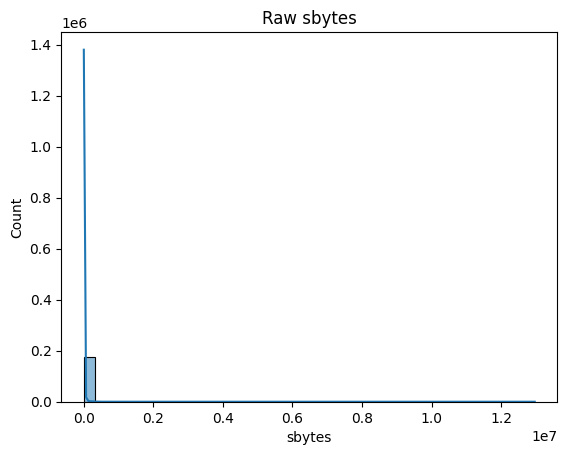

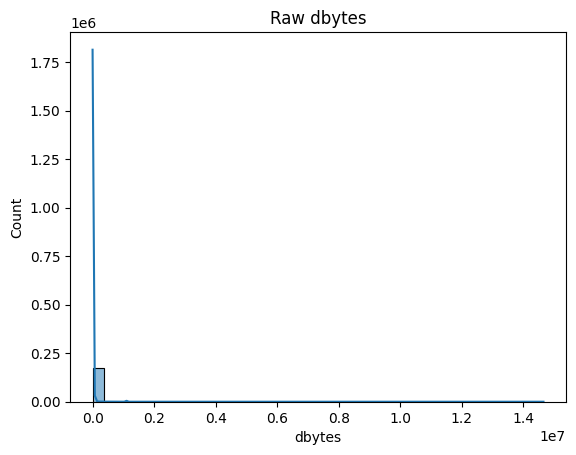

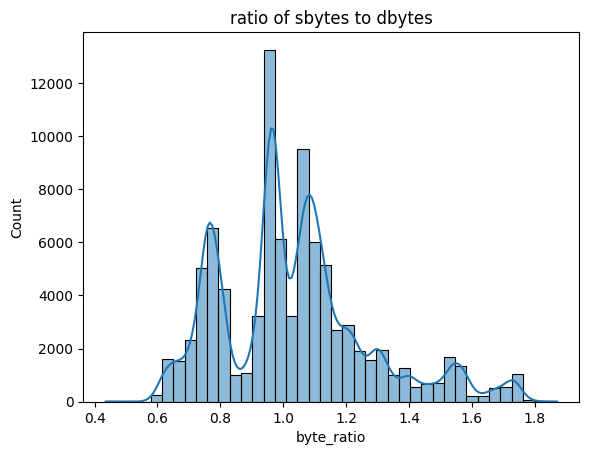

In [148]:
if "sbytes" in work_df_train_unsw.columns:
    sns.histplot(data=work_df_train_unsw, x="sbytes", bins=40, kde=True)
    plt.title("Raw sbytes")
    plt.show()
if "dbytes" in work_df_train_unsw.columns:
    sns.histplot(data=work_df_train_unsw, x="dbytes", bins=40, kde=True)
    plt.title("Raw dbytes")
    plt.show()
    sns.histplot(data=work_df_train_unsw, x="byte_ratio", bins=40, kde=True)
    plt.title("ratio of sbytes to dbytes")
    plt.show()
else:
    print("dbytes column not found, unable to produce histogram")

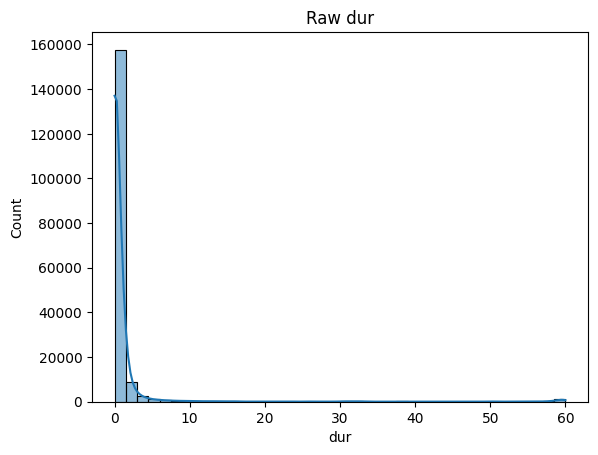

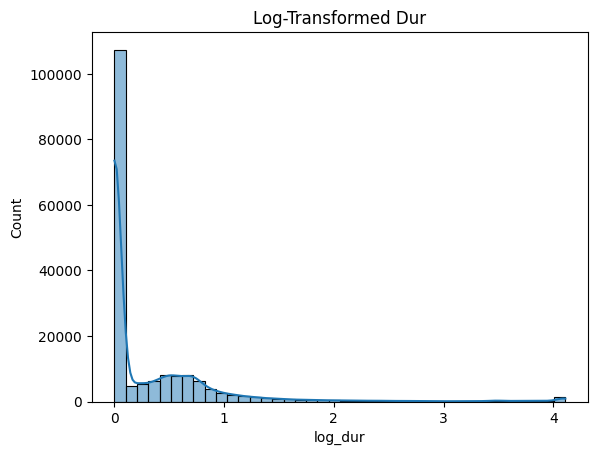

In [149]:
if "dur" in work_df_train_unsw.columns:
    sns.histplot(data=work_df_train_unsw, x="dur", bins=40, kde=True)
    plt.title("Raw dur")
    plt.show()
    sns.histplot(data=work_df_train_unsw, x="log_dur", bins=40, kde=True)
    plt.title("Log-Transformed Dur")
    plt.show()

## 10: Update the Feature List
Add the engineered features to the selected feature list.

In [150]:
final_features_phish = selected_features_phish.copy()
if "log_URLLength" in work_df_phish.columns:
    final_features_phish.append("log_URLLength")
if "log_NoOfExternalRef" in work_df_phish.columns:
    final_features_phish.append("log_NoOfExternalRef")
print("Final features:")
print(final_features_phish)

Final features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength', 'log_URLLength', 'log_NoOfExternalRef']


In [151]:
final_features_unsw = selected_features_unsw.copy()
if "log_dur" in work_df_train_unsw.columns:
    final_features_unsw.append("log_dur")
print("Final features:")
print(final_features_unsw)

Final features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl', 'log_dur']


## 11: Correlation Analysis
Create a correlation heatmap using the final numeric features and the label

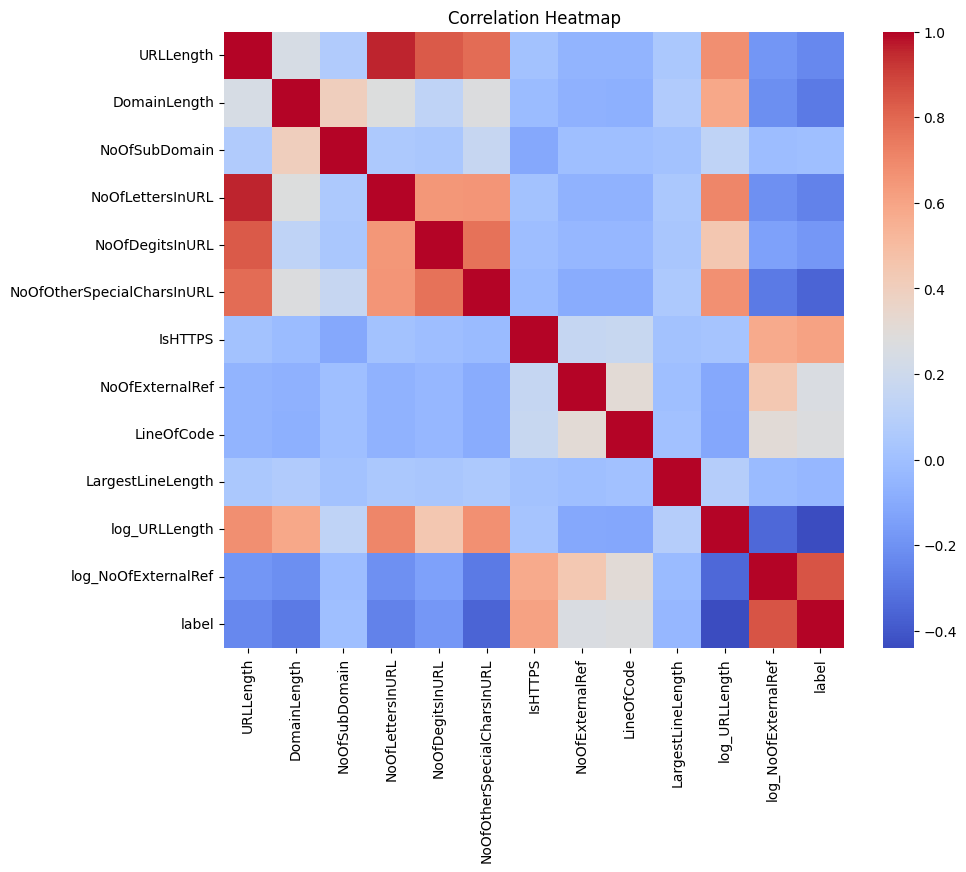

In [152]:
corr_phish = work_df_phish[final_features_phish + ["label"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_phish, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In this heat map it looks like the log_NoOfExternalRef and label correlate as well as NoOfDegitsInUrl and NoOfOtherSpecialCharsInURL. URLLength and log_URLLength are redundant since they are providing the same information. 

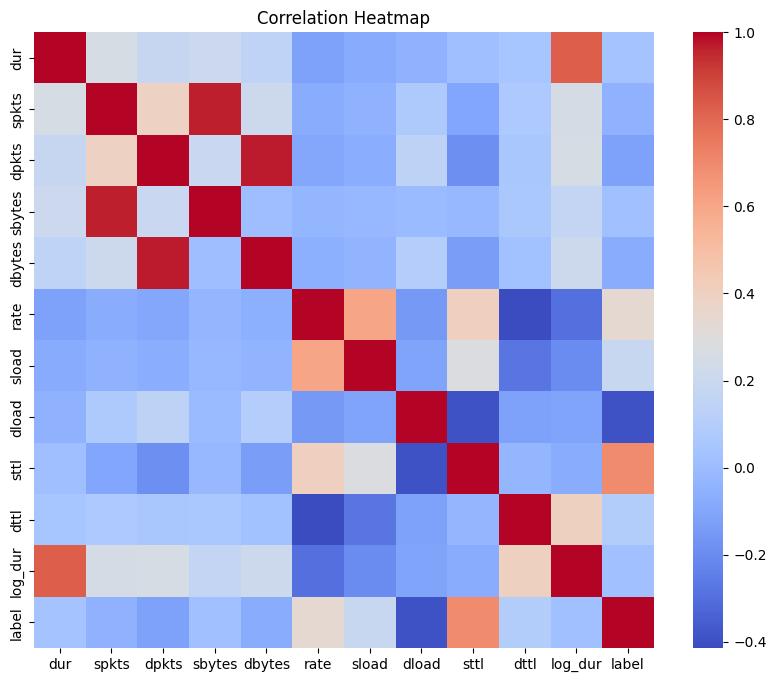

In [153]:
corr_unsw = work_df_train_unsw[final_features_unsw + ["label"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_unsw, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

There is a strong correlation between dload and sttl as well as dload and label. dur is now redundant because of log_dur. 

## 12: Create X and y

Create the feature matrix X and target vector y

In [154]:
X_phish = work_df_phish[final_features_phish]
y_phish = work_df_phish["label"]
print("X shape:", X_phish.shape)
print("y shape:", y_phish.shape)

X_unsw = work_df_train_unsw[final_features_unsw]
y_unsw = work_df_train_unsw["label"]
print("X shape:", X_unsw.shape)
print("y shape:", y_unsw.shape)

X shape: (235795, 12)
y shape: (235795,)
X shape: (175341, 11)
y shape: (175341,)


## 13: Train-Test Split

Split the data into training and testing sets. Use stratify=y to preserve class proportions

In [155]:
def trainTestSplit(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=40103
    )
    print("Training rows:", X_train.shape[0])
    print("Testing rows:", X_test.shape[0])
    print("Training class distribution:")
    print(y_train.value_counts(normalize=True).round(3))
    print("Testing class distribution:")
    print(y_test.value_counts(normalize=True).round(3))
    return X_train, X_test, y_train, y_test

X_train_phish, X_test_phish, y_train_phish, y_test_phish = trainTestSplit(X_phish, y_phish)

Training rows: 176846
Testing rows: 58949
Training class distribution:
label
1    0.572
0    0.428
Name: proportion, dtype: float64
Testing class distribution:
label
1    0.572
0    0.428
Name: proportion, dtype: float64


In [156]:
X_train_unsw = work_df_train_unsw[final_features_unsw]
y_train_unsw = work_df_train_unsw["label"]
X_test_unsw = work_df_test_unsw[final_features_unsw]
y_test_unsw = work_df_test_unsw["label"]
print("Training rows:", X_train_unsw.shape[0])
print("Testing rows:", X_test_unsw.shape[0])
print("Training class distribution:")
print(y_train_unsw.value_counts(normalize=True).round(3))
print("Testing class distribution:")
print(y_test_unsw.value_counts(normalize=True).round(3))

Training rows: 175341
Testing rows: 82332
Training class distribution:
label
1    0.681
0    0.319
Name: proportion, dtype: float64
Testing class distribution:
label
1    0.551
0    0.449
Name: proportion, dtype: float64


## 14: Fill Missing Values

Use the training median to fill missing values. Use the same training median for the test set.

In [157]:
train_medians_phish = X_train_phish.median()
X_train_clean_phish = X_train_phish.fillna(train_medians_phish)
X_test_clean_phish = X_test_phish.fillna(train_medians_phish)
print("Missing values in X_train_clean_phish:", X_train_clean_phish.isnull().sum().sum())
print("Missing values in X_test_clean_phish:", X_test_clean_phish.isnull().sum().sum())

train_medians_unsw = X_train_unsw.median()
X_train_clean_unsw = X_train_unsw.fillna(train_medians_unsw)
print("Missing values in X_train_clean_unsw:", X_train_clean_unsw.isnull().sum().sum())

X_test_clean_unsw = X_test_unsw.fillna(train_medians_unsw)
print("Missing values in X_test_clean_unsw:", X_test_clean_unsw.isnull().sum().sum())

Missing values in X_train_clean_phish: 0
Missing values in X_test_clean_phish: 0
Missing values in X_train_clean_unsw: 0
Missing values in X_test_clean_unsw: 0


## 15: Scale Numeric Features

Scale the features using StandardScaler. Fit the scaler only on the training data.

In [158]:
scaler = StandardScaler()
X_train_scaled_phish = scaler.fit_transform(X_train_clean_phish)
X_test_scaled_phish = scaler.transform(X_test_clean_phish)
print("Scaled training shape:", X_train_scaled_phish.shape)
print("Scaled testing shape:", X_test_scaled_phish.shape)

X_train_scaled_unsw = scaler.fit_transform(X_train_clean_unsw)
print("Scaled training shape:", X_train_scaled_unsw.shape)

X_test_scaled_unsw = scaler.transform(X_test_clean_unsw)
print("Scaled testing shape:", X_test_scaled_unsw.shape)

Scaled training shape: (176846, 12)
Scaled testing shape: (58949, 12)
Scaled training shape: (175341, 11)
Scaled testing shape: (82332, 11)


## 16: Train Logistic Regression

Create, train, and evaluate a Logistic Regression model.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



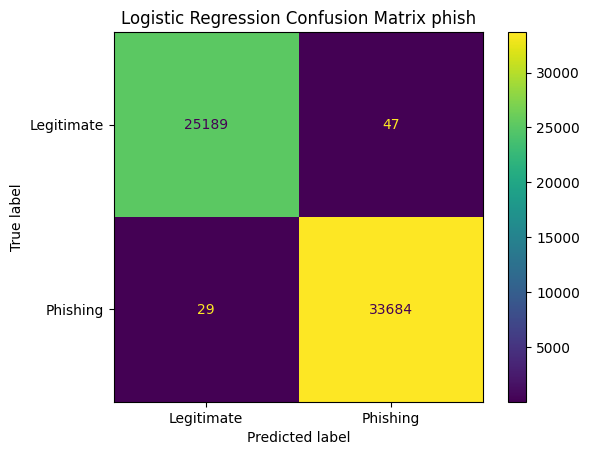

In [159]:
log_model_phish = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=40103
)
log_model_phish.fit(X_train_scaled_phish, y_train_phish)
log_pred_phish = log_model_phish.predict(X_test_scaled_phish)
print(classification_report(y_test_phish, log_pred_phish, zero_division=0))
log_cm_phish = confusion_matrix(y_test_phish, log_pred_phish)
disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm_phish,
    display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix phish")
plt.show()

              precision    recall  f1-score   support

           0       0.78      0.60      0.68     37000
           1       0.72      0.86      0.79     45332

    accuracy                           0.74     82332
   macro avg       0.75      0.73      0.73     82332
weighted avg       0.75      0.74      0.74     82332



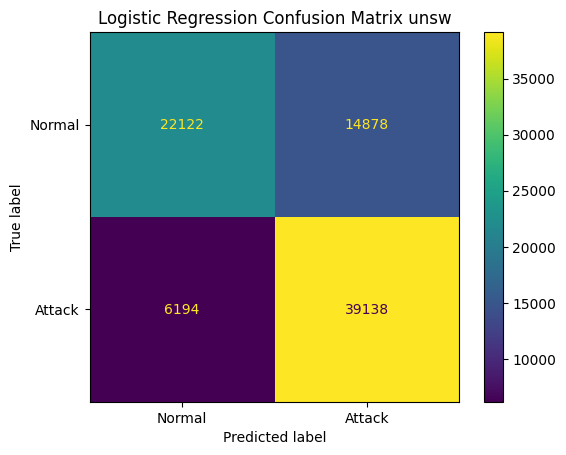

In [160]:
log_model_unsw = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=40103
)
log_model_unsw.fit(X_train_scaled_unsw, y_train_unsw)
log_pred_unsw = log_model_unsw.predict(X_test_scaled_unsw)
print(classification_report(y_test_unsw, log_pred_unsw, zero_division=0))
log_cm_unsw = confusion_matrix(y_test_unsw, log_pred_unsw)
disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm_unsw,
    display_labels=["Normal", "Attack"]
)
disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix unsw")
plt.show()

## 17: Train Decision Tree

Create, train, and evaluate a Decision Tree model.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



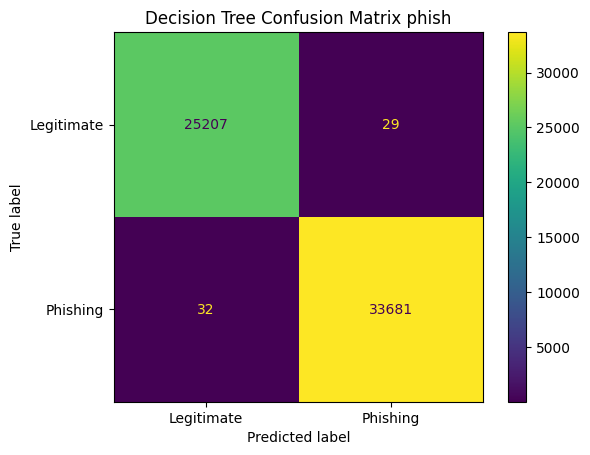

In [161]:
tree_model_phish = DecisionTreeClassifier(
    random_state=40103,
    class_weight="balanced"
)
tree_model_phish.fit(X_train_clean_phish, y_train_phish)
tree_pred_phish = tree_model_phish.predict(X_test_clean_phish)
print(classification_report(y_test_phish, tree_pred_phish, zero_division=0))
tree_cm_phish = confusion_matrix(y_test_phish, tree_pred_phish)
disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm_phish,
    display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix phish")
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.78      0.85     37000
           1       0.84      0.95      0.89     45332

    accuracy                           0.88     82332
   macro avg       0.89      0.87      0.87     82332
weighted avg       0.88      0.88      0.87     82332



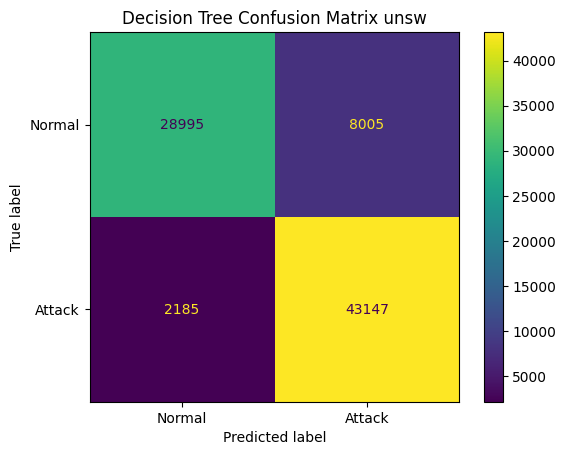

In [162]:
tree_model_unsw = DecisionTreeClassifier(
    random_state=40103,
    class_weight="balanced"
)
tree_model_unsw.fit(X_train_clean_unsw, y_train_unsw)
tree_pred_unsw = tree_model_unsw.predict(X_test_clean_unsw)
print(classification_report(y_test_unsw, tree_pred_unsw, zero_division=0))
tree_cm_unsw = confusion_matrix(y_test_unsw, tree_pred_unsw)
disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm_unsw,
    display_labels=["Normal", "Attack"]
)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix unsw")
plt.show()

## 18: Train Random Forest

Create, train, and evaluate a Random Forest model.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



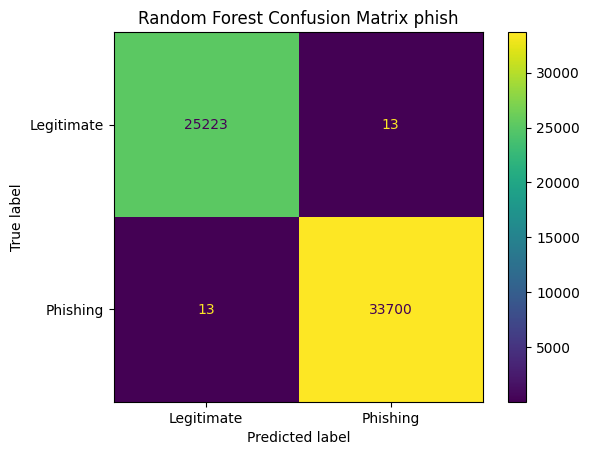

In [163]:
forest_model_phish = RandomForestClassifier(
  n_estimators=100,
  random_state=40103,
  class_weight="balanced"
)
forest_model_phish.fit(X_train_clean_phish, y_train_phish)
forest_pred_phish = forest_model_phish.predict(X_test_clean_phish)
print(classification_report(y_test_phish, forest_pred_phish, zero_division=0))
forest_cm_phish = confusion_matrix(y_test_phish, forest_pred_phish)
disp = ConfusionMatrixDisplay(
    confusion_matrix=forest_cm_phish,
    display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix phish")
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.80      0.86     37000
           1       0.85      0.95      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.89      0.88      0.88     82332
weighted avg       0.89      0.88      0.88     82332



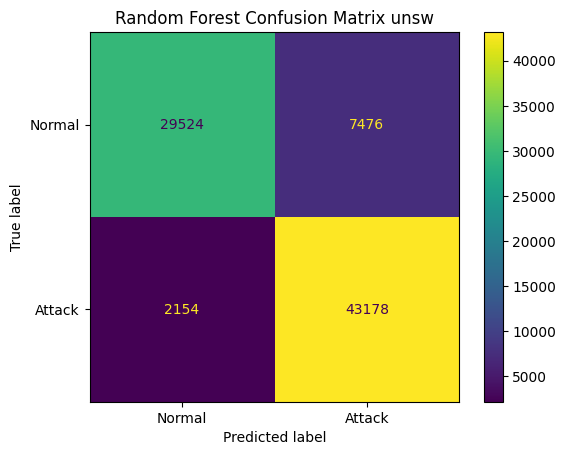

In [164]:
forest_model_unsw = RandomForestClassifier(
  n_estimators=100,
  random_state=40103,
  class_weight="balanced"
)
forest_model_unsw.fit(X_train_clean_unsw, y_train_unsw)
forest_pred_unsw = forest_model_unsw.predict(X_test_clean_unsw)
print(classification_report(y_test_unsw, forest_pred_unsw, zero_division=0))
forest_cm_unsw = confusion_matrix(y_test_unsw, forest_pred_unsw)
disp = ConfusionMatrixDisplay(
    confusion_matrix=forest_cm_unsw,
    display_labels=["Normal", "Attack"]
)
disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix unsw")
plt.show()

## 19: Create a Metric Summary Table

Create a function to compute model metrics and display a comparison table.
get_metrics()

In [165]:
def get_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
results_phish = [
    get_metrics("Logistic Regression", y_test_phish, log_pred_phish),
    get_metrics("Decision Tree", y_test_phish, tree_pred_phish),
    get_metrics("Random Forest", y_test_phish, forest_pred_phish)
]
results_phish_df = pd.DataFrame(results_phish)
results_phish_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.998711,0.998607,0.999140,0.998873
1,Decision Tree,0.998965,0.999140,0.999051,0.999095
2,Random Forest,0.999559,0.999614,0.999614,0.999614


In [166]:
results_unsw = [
    get_metrics("Logistic Regression", y_test_unsw, log_pred_unsw),
    get_metrics("Decision Tree", y_test_unsw, tree_pred_unsw),
    get_metrics("Random Forest", y_test_unsw, forest_pred_unsw)
]
results_unsw_df = pd.DataFrame(results_unsw)
results_unsw_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.744061,0.724563,0.863364,0.787897
1,Decision Tree,0.876233,0.843506,0.951800,0.894387
2,Random Forest,0.883035,0.852410,0.952484,0.899673


## 20: Stratified k-Fold Cross-Validation

Use stratified 5-fold cross-validation to evaluate all three models 

In [167]:
cv_phish = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40103
)
scoring = ["accuracy", "precision", "recall", "f1"]
X_clean = X_train_phish.fillna(X_train_phish.median())
X_scaled = scaler.fit_transform(X_clean)
log_cv_phish = cross_validate(
 log_model_phish,
 X_scaled,
 y_train_phish,
 cv=cv_phish,
 scoring=scoring,
    n_jobs=-1
)
tree_cv_phish = cross_validate(
    tree_model_phish,
    X_clean,
    y_train_phish,
    cv=cv_phish,
    scoring=scoring,
    n_jobs=-1
)
forest_cv_phish = cross_validate(
    forest_model_phish,
    X_clean,
    y_train_phish,
    cv=cv_phish,
    scoring=scoring,
    n_jobs=-1
)
cv_summary_phish = pd.DataFrame([
    {
        "Model": "Logistic Regression phish",
        "Accuracy": log_cv_phish["test_accuracy"].mean(),
        "Precision": log_cv_phish["test_precision"].mean(),
        "Recall": log_cv_phish["test_recall"].mean(),
        "F1": log_cv_phish["test_f1"].mean()
    },
    {
        "Model": "Decision Tree phish",
        "Accuracy": tree_cv_phish["test_accuracy"].mean(),
        "Precision": tree_cv_phish["test_precision"].mean(),
        "Recall": tree_cv_phish["test_recall"].mean(),
        "F1": tree_cv_phish["test_f1"].mean()
    },
    {
        "Model": "Random Forest phish",
        "Accuracy": forest_cv_phish["test_accuracy"].mean(),
        "Precision": forest_cv_phish["test_precision"].mean(),
        "Recall": forest_cv_phish["test_recall"].mean(),
        "F1": forest_cv_phish["test_f1"].mean()
    }
])
cv_summary_phish

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression phish,0.998513,0.998478,0.998922,0.998700
1,Decision Tree phish,0.998841,0.998893,0.999080,0.998987
2,Random Forest phish,0.999355,0.999545,0.999328,0.999436


In [168]:
cv_unsw = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40103
)
scoring = ["accuracy", "precision", "recall", "f1"]
X_clean = X_unsw.fillna(X_unsw.median())
X_scaled = scaler.fit_transform(X_clean)
log_cv_unsw = cross_validate(
 log_model_unsw,
 X_scaled,
 y_unsw,
 cv=cv_unsw,
 scoring=scoring,
    n_jobs=-1
)
tree_cv_unsw = cross_validate(
    tree_model_unsw,
    X_clean,
    y_unsw,
    cv=cv_unsw,
    scoring=scoring,
    n_jobs=-1
)
forest_cv_unsw = cross_validate(
    forest_model_unsw,
    X_clean,
    y_unsw,
    cv=cv_unsw,
    scoring=scoring,
    n_jobs=-1
)
cv_summary_unsw = pd.DataFrame([
    {
        "Model": "Logistic Regression unsw",
        "Accuracy": log_cv_unsw["test_accuracy"].mean(),
        "Precision": log_cv_unsw["test_precision"].mean(),
        "Recall": log_cv_unsw["test_recall"].mean(),
        "F1": log_cv_unsw["test_f1"].mean()
    },
    {
        "Model": "Decision Tree unsw",
        "Accuracy": tree_cv_unsw["test_accuracy"].mean(),
        "Precision": tree_cv_unsw["test_precision"].mean(),
        "Recall": tree_cv_unsw["test_recall"].mean(),
        "F1": tree_cv_unsw["test_f1"].mean()
    },
    {
        "Model": "Random Forest unsw",
        "Accuracy": forest_cv_unsw["test_accuracy"].mean(),
        "Precision": forest_cv_unsw["test_precision"].mean(),
        "Recall": forest_cv_unsw["test_recall"].mean(),
        "F1": forest_cv_unsw["test_f1"].mean()
    }
])
cv_summary_unsw

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression unsw,0.848250,0.903381,0.870112,0.886430
1,Decision Tree unsw,0.936415,0.958464,0.947646,0.953024
2,Random Forest unsw,0.938372,0.961340,0.947562,0.954400


- Stratified cross-validation is important in cybersecurity datasets, because attacks and phishing are usually far less common than normal behavior or traffic. This can make the data set imbalanced when splitting it up. Stratification makes sure that the data stays proportionate and does not create bias in the model. 

- The cv score for the phishing dataset is pretty spot-on with the test-set results. For the UNSW dataset the test-set results had a bigger gap. The actual test results range from .05 to .10 for test results compared to cv results. 

## 21: Hyperparameter Tuning for Decision Tree and Random Forest


In [169]:
param_grid_phish = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
tree_grid_phish = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid_phish,
    cv=cv_phish,
    scoring="f1",
    n_jobs=-1
)
tree_grid_phish.fit(X_train_clean_phish, y_train_phish)
print("Best parameters:")
print(tree_grid_phish.best_params_)
print("Best cross-validation F1:")
print(tree_grid_phish.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1:
0.9989866323357453


In [170]:
param_grid_unsw = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
tree_grid_unsw = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid_unsw,
    cv=cv_unsw,
    scoring="f1",
    n_jobs=-1
)
tree_grid_unsw.fit(X_train_clean_unsw, y_train_unsw)
print("Best parameters:")
print(tree_grid_unsw.best_params_)
print("Best cross-validation F1:")
print(tree_grid_unsw.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1:
0.9530241772716712


In [171]:
param_grid_phish_forest = {
    "n_estimators": [100],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}
forest_grid_phish = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid_phish_forest,
    cv=cv_phish,
    scoring="f1",
    n_jobs=-1
)
forest_grid_phish.fit(X_train_clean_phish, y_train_phish)
print("Best parameters:")
print(forest_grid_phish.best_params_)
print("Best cross-validation F1:")
print(forest_grid_phish.best_score_)

Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best cross-validation F1:
0.9994363416312216


In [172]:
param_grid_unsw_forest = {
    "n_estimators": [100],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}
forest_grid_unsw = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid_unsw_forest,
    cv=cv_unsw,
    scoring="f1",
    n_jobs=-1
)
forest_grid_unsw.fit(X_train_clean_unsw, y_train_unsw)
print("Best parameters:")
print(forest_grid_unsw.best_params_)
print("Best cross-validation F1:")
print(forest_grid_unsw.best_score_)

Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Best cross-validation F1:
0.9545749272703159


## 22: Evaluate the Tuned Decision Tree
Use the best Decision Tree model to predict the test set.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



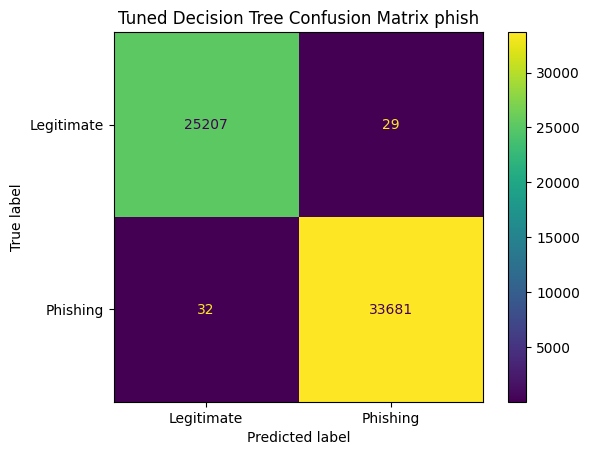

In [173]:
best_tree_phish = tree_grid_phish.best_estimator_
tuned_tree_pred_phish = best_tree_phish.predict(X_test_clean_phish)
print(classification_report(y_test_phish, tuned_tree_pred_phish, zero_division=0))
tuned_cm_tree_phish = confusion_matrix(y_test_phish, tuned_tree_pred_phish)
disp_tree_phish = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm_tree_phish,
    display_labels=["Legitimate", "Phishing"]
)
disp_tree_phish.plot(values_format="d")
plt.title("Tuned Decision Tree Confusion Matrix phish")
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.78      0.85     37000
           1       0.84      0.95      0.89     45332

    accuracy                           0.88     82332
   macro avg       0.89      0.87      0.87     82332
weighted avg       0.88      0.88      0.87     82332



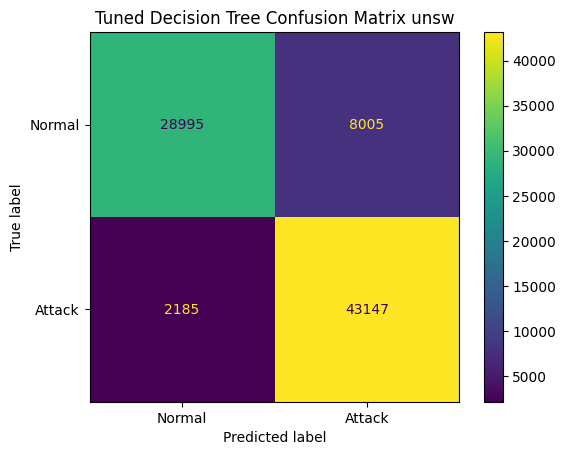

In [174]:
best_tree_unsw = tree_grid_unsw.best_estimator_
tuned_tree_pred_unsw = best_tree_unsw.predict(X_test_clean_unsw)
print(classification_report(y_test_unsw, tuned_tree_pred_unsw, zero_division=0))
tuned_cm_unsw = confusion_matrix(y_test_unsw, tuned_tree_pred_unsw)
disp_unsw = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm_unsw,
    display_labels=["Normal", "Attack"]
)
disp_unsw.plot(values_format="d")
plt.title("Tuned Decision Tree Confusion Matrix unsw")
plt.show()

## 23 Evaluate the tuned Random Forest

Use the best Random Forest model to predict the test set.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



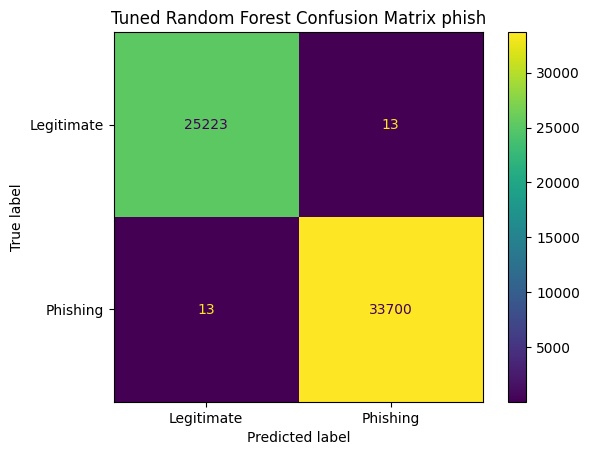

In [175]:
best_forest_phish = forest_grid_phish.best_estimator_
tuned_forest_pred_phish = best_forest_phish.predict(X_test_clean_phish)
print(classification_report(y_test_phish, tuned_forest_pred_phish, zero_division=0))
tuned_cm_forest_phish = confusion_matrix(y_test_phish, tuned_forest_pred_phish)
disp_forest_phish = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm_forest_phish,
    display_labels=["Legitimate", "Phishing"]
)
disp_forest_phish.plot(values_format="d")
plt.title("Tuned Random Forest Confusion Matrix phish")
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.81      0.87     37000
           1       0.86      0.95      0.90     45332

    accuracy                           0.89     82332
   macro avg       0.90      0.88      0.89     82332
weighted avg       0.89      0.89      0.89     82332



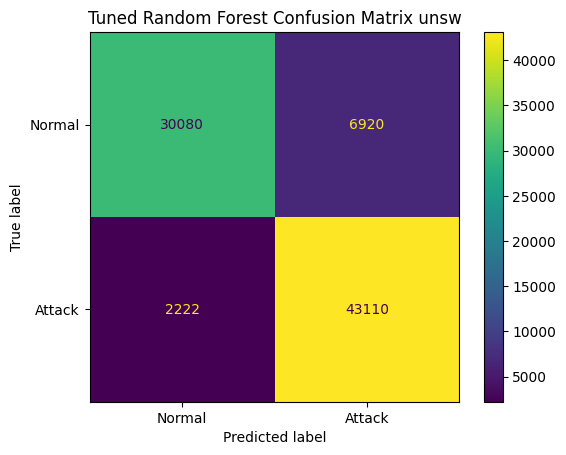

In [176]:
best_forest_unsw = forest_grid_unsw.best_estimator_
tuned_forest_pred_unsw = best_forest_unsw.predict(X_test_clean_unsw)
print(classification_report(y_test_unsw, tuned_forest_pred_unsw, zero_division=0))
tuned_cm_forest_unsw = confusion_matrix(y_test_unsw, tuned_forest_pred_unsw)
disp_forest_unsw = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm_forest_unsw,
    display_labels=["Normal", "Attack"]
)
disp_forest_unsw.plot(values_format="d")
plt.title("Tuned Random Forest Confusion Matrix unsw")
plt.show()

## 24: Comparison Table
Create a table comparing all three model versions

In [177]:
final_results_phish = [
    get_metrics("Logistic Regression phish", y_test_phish, log_pred_phish),
    get_metrics("Decision Tree phish", y_test_phish, tree_pred_phish),
    get_metrics("Tuned Decision Tree phish", y_test_phish, tuned_tree_pred_phish),
    get_metrics("Random Forest phish", y_test_phish, forest_pred_phish),
    get_metrics("Tuned Random Forest phish", y_test_phish, tuned_forest_pred_phish)
]
final_results_phish_df = pd.DataFrame(final_results_phish)
final_results_phish_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression phish,0.998711,0.998607,0.999140,0.998873
1,Decision Tree phish,0.998965,0.999140,0.999051,0.999095
2,Tuned Decision Tree phish,0.998965,0.999140,0.999051,0.999095
3,Random Forest phish,0.999559,0.999614,0.999614,0.999614
4,Tuned Random Forest phish,0.999559,0.999614,0.999614,0.999614


In [178]:
final_results_unsw = [
    get_metrics("Logistic Regression unsw", y_test_unsw, log_pred_unsw),
    get_metrics("Decision Tree unsw", y_test_unsw, tree_pred_unsw),
    get_metrics("Tuned Decision Tree unsw", y_test_unsw, tuned_tree_pred_unsw),
    get_metrics("Random Forest unsw", y_test_unsw, forest_pred_unsw),
    get_metrics("Tuned Random Forest unsw", y_test_unsw, tuned_forest_pred_unsw)
]
final_results_unsw_df = pd.DataFrame(final_results_unsw)
final_results_unsw_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression unsw,0.744061,0.724563,0.863364,0.787897
1,Decision Tree unsw,0.876233,0.843506,0.951800,0.894387
2,Tuned Decision Tree unsw,0.876233,0.843506,0.951800,0.894387
3,Random Forest unsw,0.883035,0.852410,0.952484,0.899673
4,Tuned Random Forest unsw,0.888962,0.861683,0.950984,0.904134


## 25: ROC-AUC Analysis

Compute ROC-AUC and plot ROC curves for the models that produce probability scores
(Logistic Regression and Random Forest) on both datasets. 

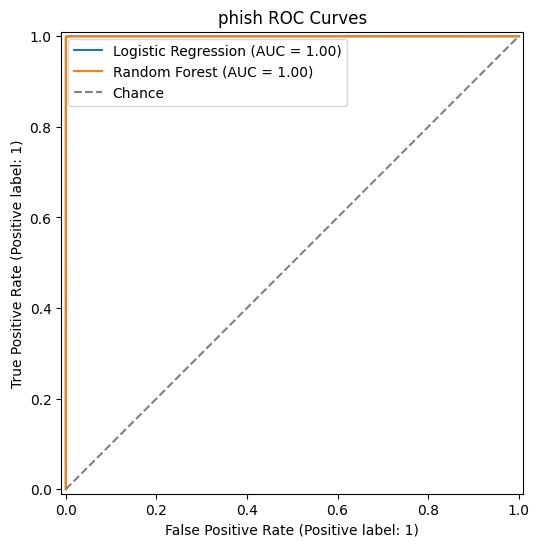

phish Logistic Regression ROC-AUC: 1.0000
phish Random Forest      ROC-AUC: 1.0000


In [179]:
phish_lr_proba = log_model_phish.predict_proba(X_test_scaled_phish)[:, 1]
phish_rf_proba = forest_model_phish.predict_proba(X_test_clean_phish)[:, 1]

auc_lr_phish = roc_auc_score(y_test_phish, phish_lr_proba)
auc_rf_phish = roc_auc_score(y_test_phish, phish_rf_proba)

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test_phish, phish_lr_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test_phish, phish_rf_proba, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("phish ROC Curves")
ax.legend()
plt.show()

print(f"phish Logistic Regression ROC-AUC: {auc_lr_phish:.4f}")
print(f"phish Random Forest      ROC-AUC: {auc_rf_phish:.4f}")

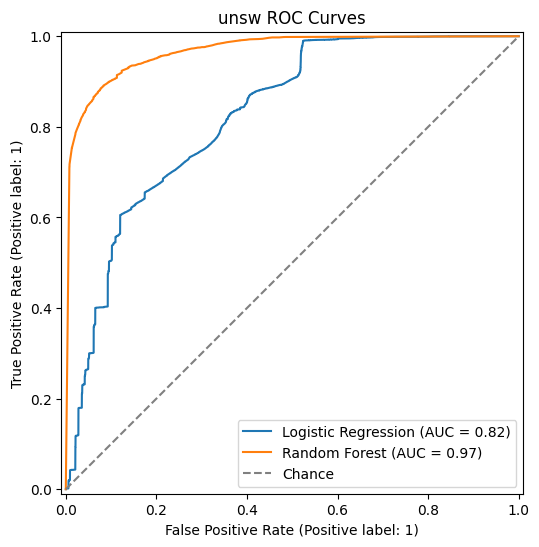

unsw Logistic Regression ROC-AUC: 0.8248
unsw Random Forest      ROC-AUC: 0.9679


In [180]:
unsw_lr_proba = log_model_unsw.predict_proba(X_test_scaled_unsw)[:, 1]
unsw_rf_proba = forest_model_unsw.predict_proba(X_test_clean_unsw)[:, 1]

auc_lr_unsw = roc_auc_score(y_test_unsw, unsw_lr_proba)
auc_rf_unsw = roc_auc_score(y_test_unsw, unsw_rf_proba)

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test_unsw, unsw_lr_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test_unsw, unsw_rf_proba, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("unsw ROC Curves")
ax.legend()
plt.show()

print(f"unsw Logistic Regression ROC-AUC: {auc_lr_unsw:.4f}")
print(f"unsw Random Forest      ROC-AUC: {auc_rf_unsw:.4f}")

In [181]:
roc_results_df = pd.DataFrame([
    {"Dataset": "phish",  "Model": "Logistic Regression", "ROC-AUC": auc_lr_phish},
    {"Dataset": "phish",  "Model": "Random Forest",       "ROC-AUC": auc_rf_phish},
    {"Dataset": "unsw", "Model": "Logistic Regression", "ROC-AUC": auc_lr_unsw},
    {"Dataset": "unsw", "Model": "Random Forest",       "ROC-AUC": auc_rf_unsw},
])
roc_results_df

,Dataset,Model,ROC-AUC
0,phish,Logistic Regression,0.999990
1,phish,Random Forest,0.999978
2,unsw,Logistic Regression,0.824801
3,unsw,Random Forest,0.967922


**What ROC-AUC measures.** 
- The roc curve measures the true positive rate against the false positive rate on a graph. The 
closer the area under the curve is to 1 the better the model is at making the correct predictions. 

**Why ROC-AUC alone is not enough for imbalanced security data.** 
- The curve fails when the data set is imbalanced, like it often is in a security dataset. Attacks are far less common 
than regular behavior. For instance if you received 10,000 emails and only 5 were bad then if the model predicted that 200 were bad
that would make a ton of noise for anyone actually investigating the traffic, but the curve would not really move because 
only 200/ 10,000 were flagged wrong, so the false positive rate seems fine. 

## Security Interpretations

PhiUSIIL:
- The best performing model is the random forest model
- The random forest model had the best recall
- False positives are probably more dangerous in phishing detection because users will start to lose valuable information and would lose trust in the model.
- I would probably not deploy the best model, just because I think I am pretty good at detecting phishing emails and would rather validate on my own and not have anything wrongly marked as phishing. Or maybe I would use the Decision Tree if I had to chose one just because it looks like it has the best precision. 

UNSW:
- Random forest is the best model
- Random forest had the best recall
- I think false negatives are more dangerous for intrusion detection since if an attack is successful you could be in a whole heap of trouble and really sensitive information could be compromised. 
- I would deploy the best performing model just because it would feel like an extra layer of protection that couldn't really hurt. 

## AI Statement
- I used claude code to help me generate the ROC curves and also to choose reasonable values for the random forest model. I used google to get a better understanding of concepts, would write out what my thoughts were and then would ask claude to review what I had written and if it said I was wrong I would go back to google and try to get a better understanding.